### Análise de Tráfego Aéreo em Aeroportos Internacionais

### 📌 Contexto do Problema

**O setor de transporte aéreo é altamente sensível a eventos econômicos, políticos e sanitários. Mudanças no volume de tráfego aéreo impactam diretamente:**

    companhias aéreas
    aeroportos
    turismo
    logística internacional

**Neste projeto realizamos uma análise exploratória de dados (EDA) sobre o tráfego aéreo em aeroportos de diferentes países.**

***O objetivo é identificar:***

    padrões de tráfego por país
    aeroportos com maior movimento
    cidades com maior concentração de voos
    comportamento do tráfego em relação ao baseline histórico

* A métrica PercentOfBaseline representa o percentual do tráfego aéreo em relação a um período de referência histórico.

Exemplo:

100% → tráfego normal

50% → metade do tráfego habitual

## Instalando e Carregando os Pacotes

In [1]:
# Imports
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("dados/dataset5.csv")

In [3]:
df.shape

(7247, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7247 entries, 0 to 7246
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AggregationMethod  7247 non-null   object 
 1   Date               7247 non-null   object 
 2   Version            7247 non-null   float64
 3   AirportName        7247 non-null   object 
 4   PercentOfBaseline  7247 non-null   int64  
 5   Centroid           7247 non-null   object 
 6   City               7247 non-null   object 
 7   State              7247 non-null   object 
 8   ISO_3166_2         7247 non-null   object 
 9   Country            7247 non-null   object 
 10  Geography          7247 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 622.9+ KB


#### Observações:

✔ Não existem valores nulos
✔ Dados categóricos predominam
✔ Apenas duas variáveis numéricas principais

In [5]:
df.head()

,AggregationMethod,Date,Version,AirportName,PercentOfBaseline,Centroid,City,State,ISO_3166_2,Country,Geography
0,Daily,2020-04-03,1.0,Kingsford Smith,64,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
1,Daily,2020-04-13,1.0,Kingsford Smith,29,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
2,Daily,2020-07-10,1.0,Kingsford Smith,54,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
3,Daily,2020-09-02,1.0,Kingsford Smith,18,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."
4,Daily,2020-10-31,1.0,Kingsford Smith,22,POINT(151.180087713813 -33.9459774986125),Sydney,New South Wales,AU,Australia,"POLYGON((151.164354085922 -33.9301772341877, 1..."


In [6]:
df.isna().sum()

AggregationMethod    0
Date                 0
Version              0
AirportName          0
PercentOfBaseline    0
Centroid             0
City                 0
State                0
ISO_3166_2           0
Country              0
Geography            0
dtype: int64

In [7]:
df.describe()

,Version,PercentOfBaseline
count,7247.0,7247.000000
mean,1.0,66.651442
std,0.0,22.134433
min,1.0,0.000000
25%,1.0,53.000000
50%,1.0,67.000000
75%,1.0,84.000000
max,1.0,100.000000


**Gráfico de barras na horizontal com o tráfego aéreo por país**

Primeiro analisamos como o tráfego se distribui entre países.

In [8]:
df["Country"].unique()

array(['Australia', 'Chile', 'Canada', 'United States of America (the)'],
      dtype=object)

Text(0, 0.5, 'País')

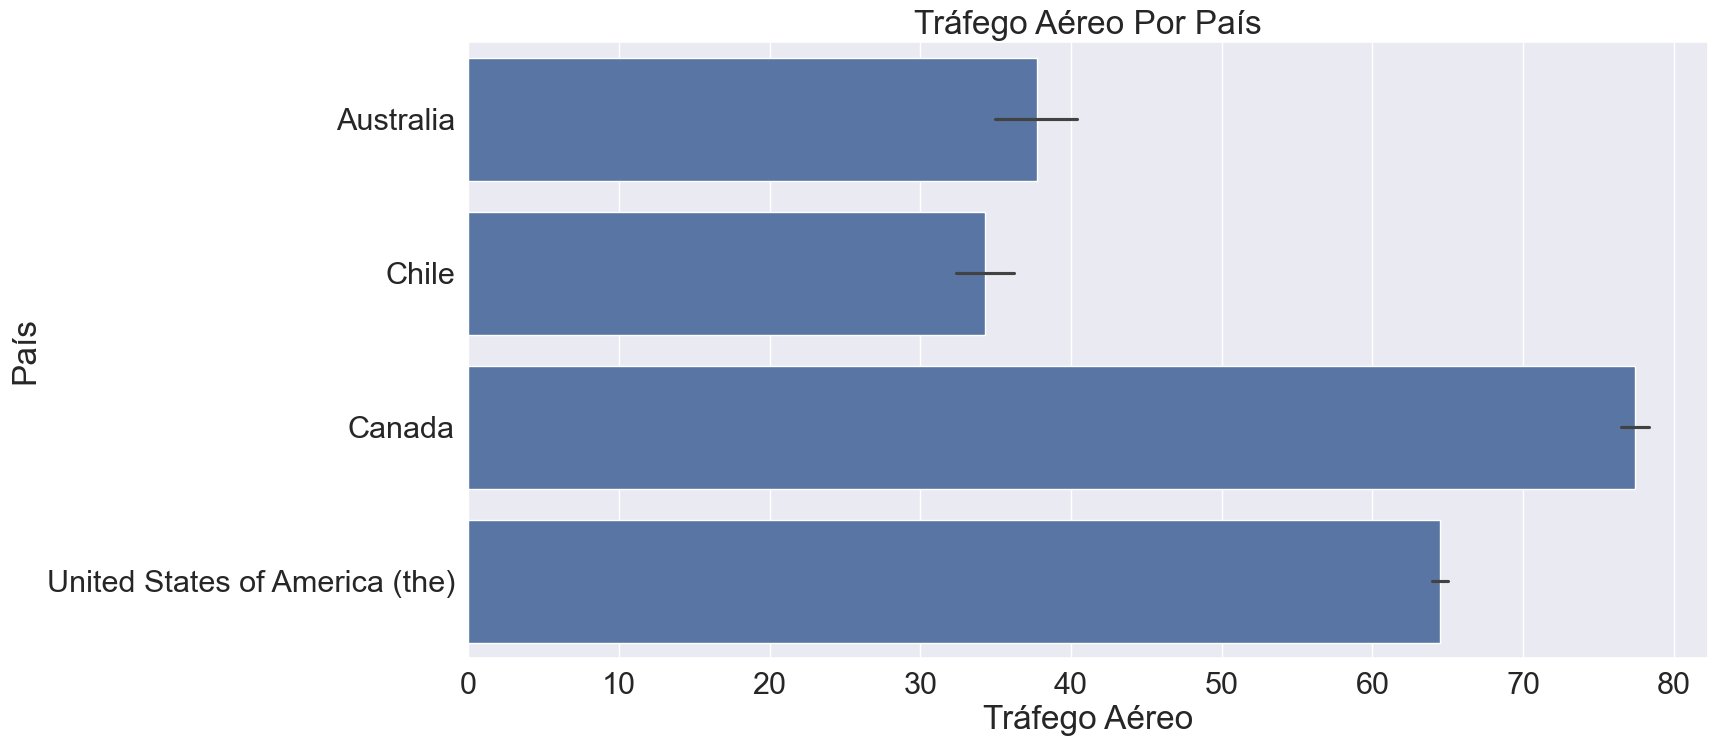

In [9]:
# Dataviz 30
sns.set(font_scale = 2)
plt.figure(figsize = (16,8))
sns.barplot(x = "PercentOfBaseline", y = "Country", data = df)
plt.title("Tráfego Aéreo Por País")
plt.xlabel('Tráfego Aéreo')
plt.ylabel('País')

Os dados mostram diferenças claras entre países.

Possíveis explicações:

    restrições de mobilidade
    volume de voos domésticos
    tamanho do mercado aéreo

#### Distribuição de Registros por País

**Gráfico de pizza com o tráfego aéreo por país**

In [10]:
# Ajusta os dados
trafego_paises = df['Country'].value_counts().to_frame('Count')
trafego_paises

,Count
Country,
United States of America (the),4441
Canada,2311
Australia,257
Chile,238


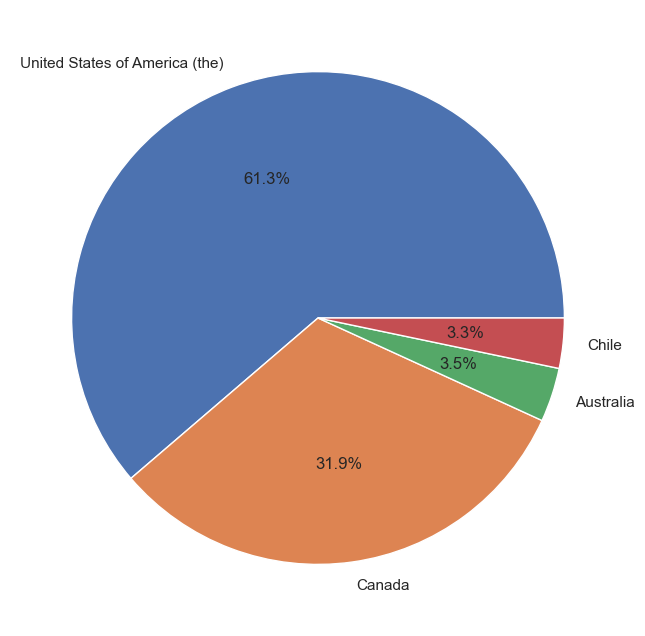

In [11]:
# Dataviz 31
sns.set(font_scale = 1)
plt.figure(figsize = (8, 8))
plt.pie(trafego_paises['Count'], 
        labels = trafego_paises.index, 
        autopct = '%1.1f%%')
plt.show()

Os dados estão concentrados principalmente em:

    Estados Unidos
    Canadá

Isso ocorre porque:

    possuem maior número de aeroportos analisados
    possuem maior volume de voos

#### Tráfego Aéreo por Cidade

Agora analisamos a distribuição do tráfego por cidade.

**Gráfico de barras na horizontal com o tráfego aéreo por cidade**

In [12]:
df["City"].unique()

array(['Sydney', 'Santiago', 'Calgary', 'Leduc County', 'Richmond',
       'Winnipeg', 'Halifax', 'Mississauga', 'Hamilton', 'Mirabel',
       'Dorval', 'Los Angeles', 'South San Francisco', 'Denver',
       'Miami Springs', 'College Park', 'Urban Honolulu', 'Chicago',
       'Boston', 'Romulus', 'Charlotte', 'Newark', 'Paradise', 'New York',
       'Grapevine', 'Floris', 'SeaTac'], dtype=object)

Text(0, 0.5, 'Cidade')

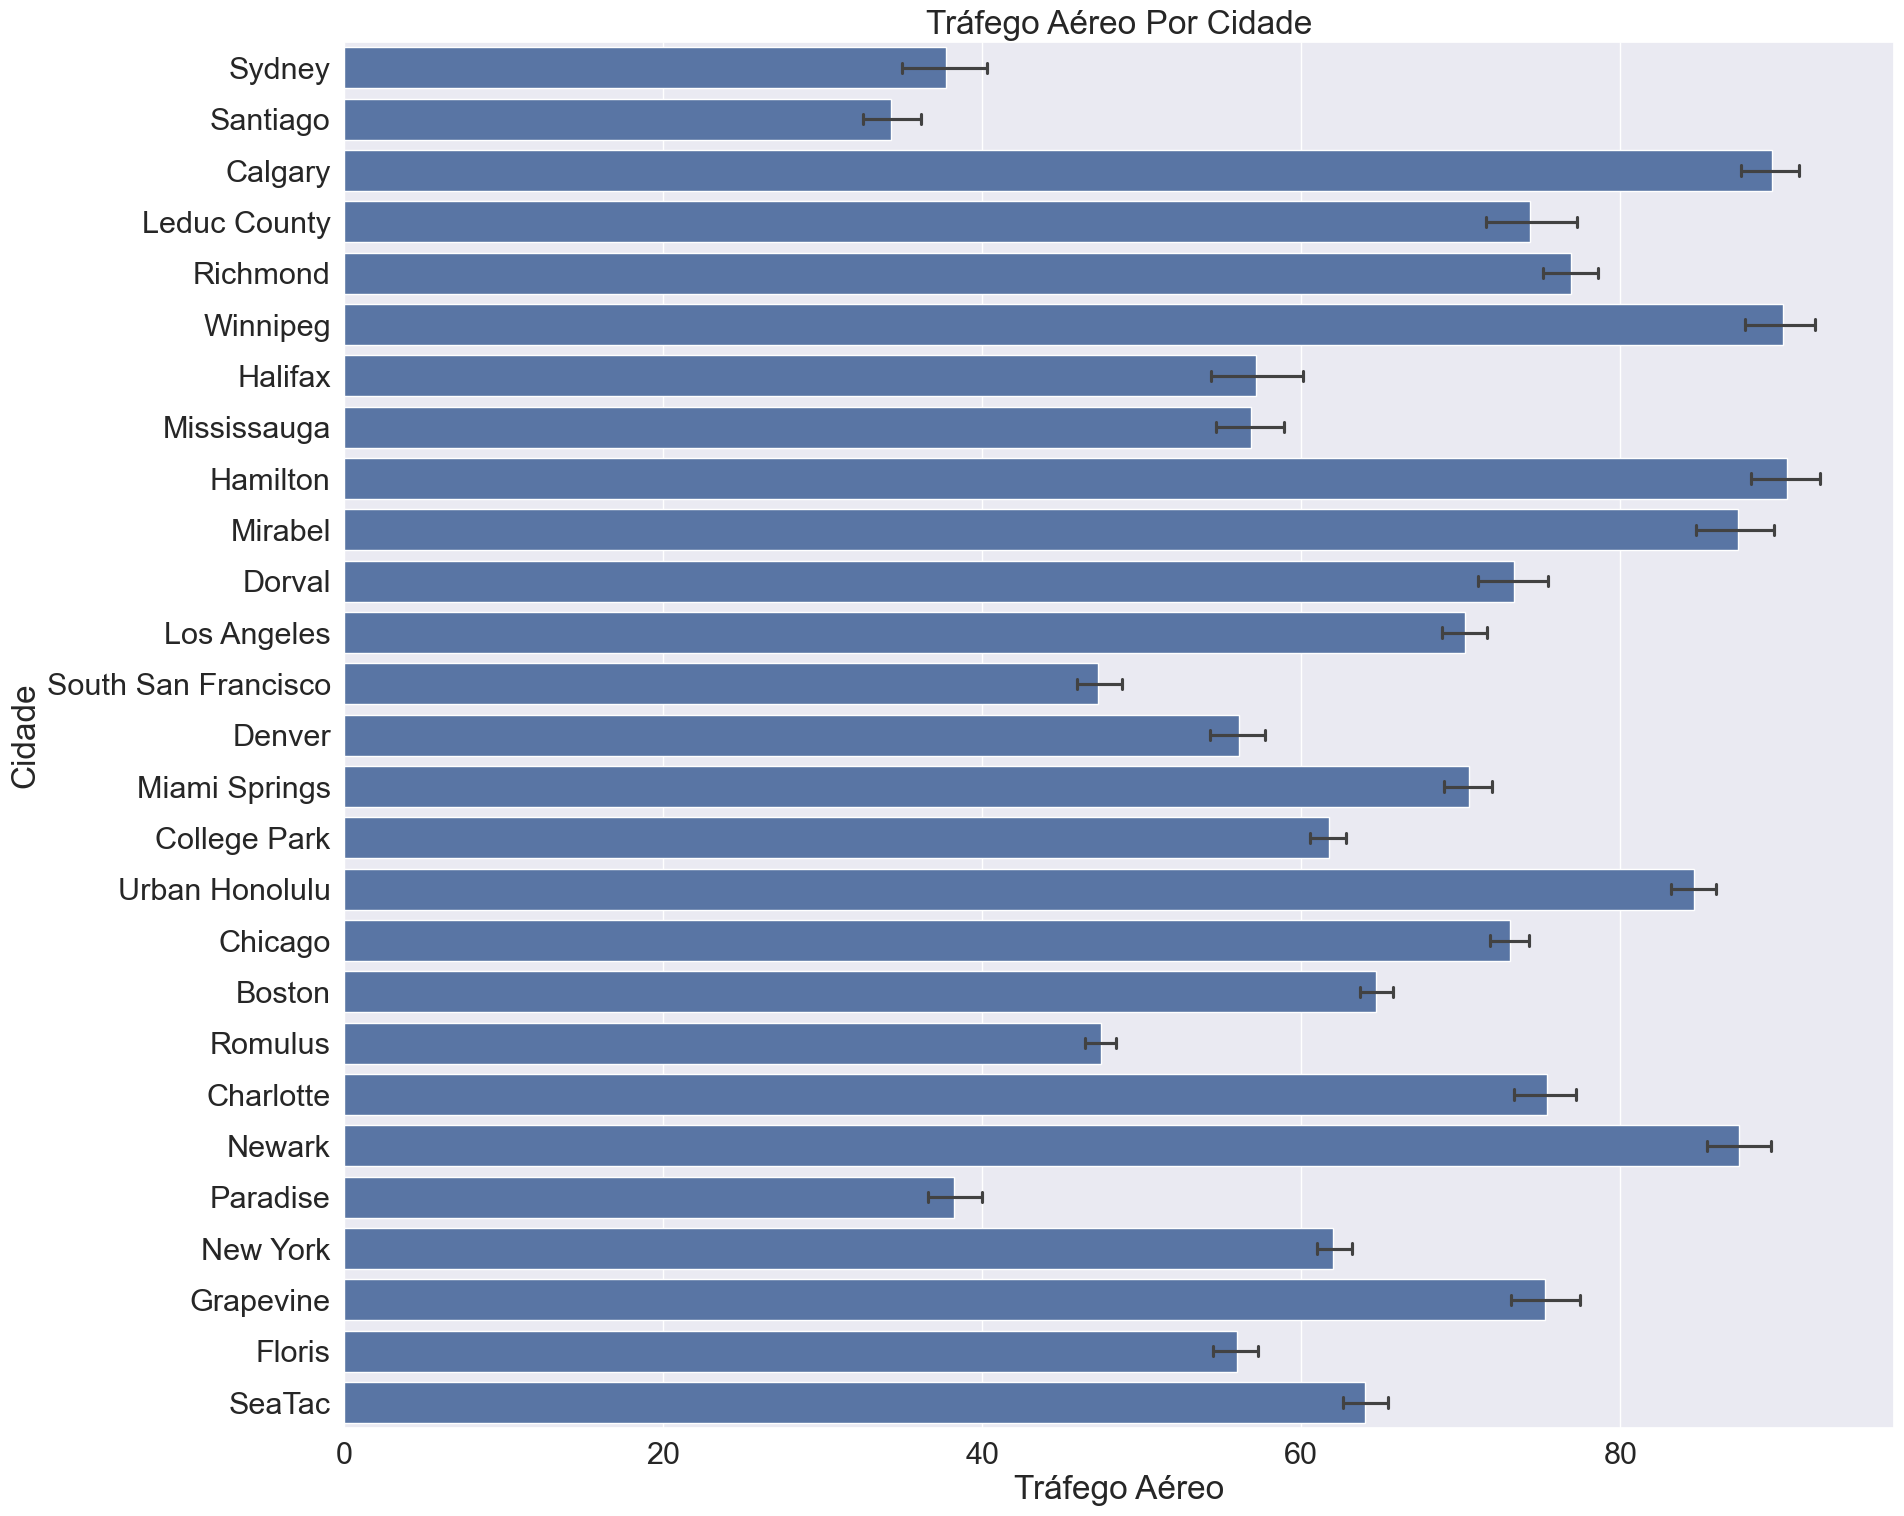

In [13]:
# Dataviz

sns.set(font_scale = 2)
plt.figure(figsize = (20,18))
sns.barplot(x = df.PercentOfBaseline, y = df.City, capsize = .2)
plt.title("Tráfego Aéreo Por Cidade")
plt.xlabel('Tráfego Aéreo')
plt.ylabel('Cidade')

Cidades com aeroportos internacionais tendem a apresentar maior estabilidade de tráfego.

Cidades analisadas incluem:

    Los Angeles
    New York
    Chicago
    Miami
    Denver

Essas cidades são principais hubs de transporte aéreo global.

#### Tráfego Aéreo por Aeroporto

**Gráfico de barras na horizontal com o tráfego aéreo por aeroporto**

In [14]:
df["AirportName"].unique()

array(['Kingsford Smith', 'Santiago International Airport',
       'Calgary International', 'Edmonton International',
       'Vancouver International', 'Winnipeg International',
       'Halifax International', 'Toronto Pearson',
       'Hamilton International', 'Montreal Mirabel', 'Montreal Trudeau',
       'Los Angeles International', 'San Francisco International',
       'Denver International', 'Miami International ',
       'Hartsfield-Jackson Atlanta International ',
       'Daniel K. Inouye International ', 'Chicago OHare International',
       'Boston Logan International ',
       'Detroit Metropolitan Wayne County ',
       'Charlotte Douglas International', 'Newark Liberty International ',
       'McCarran International', 'LaGuardia',
       'John F. Kennedy International',
       'Dallas/Fort Worth International ',
       'Washington Dulles International ',
       'Seattle-Tacoma International '], dtype=object)

Text(0, 0.5, 'Aeroporto')

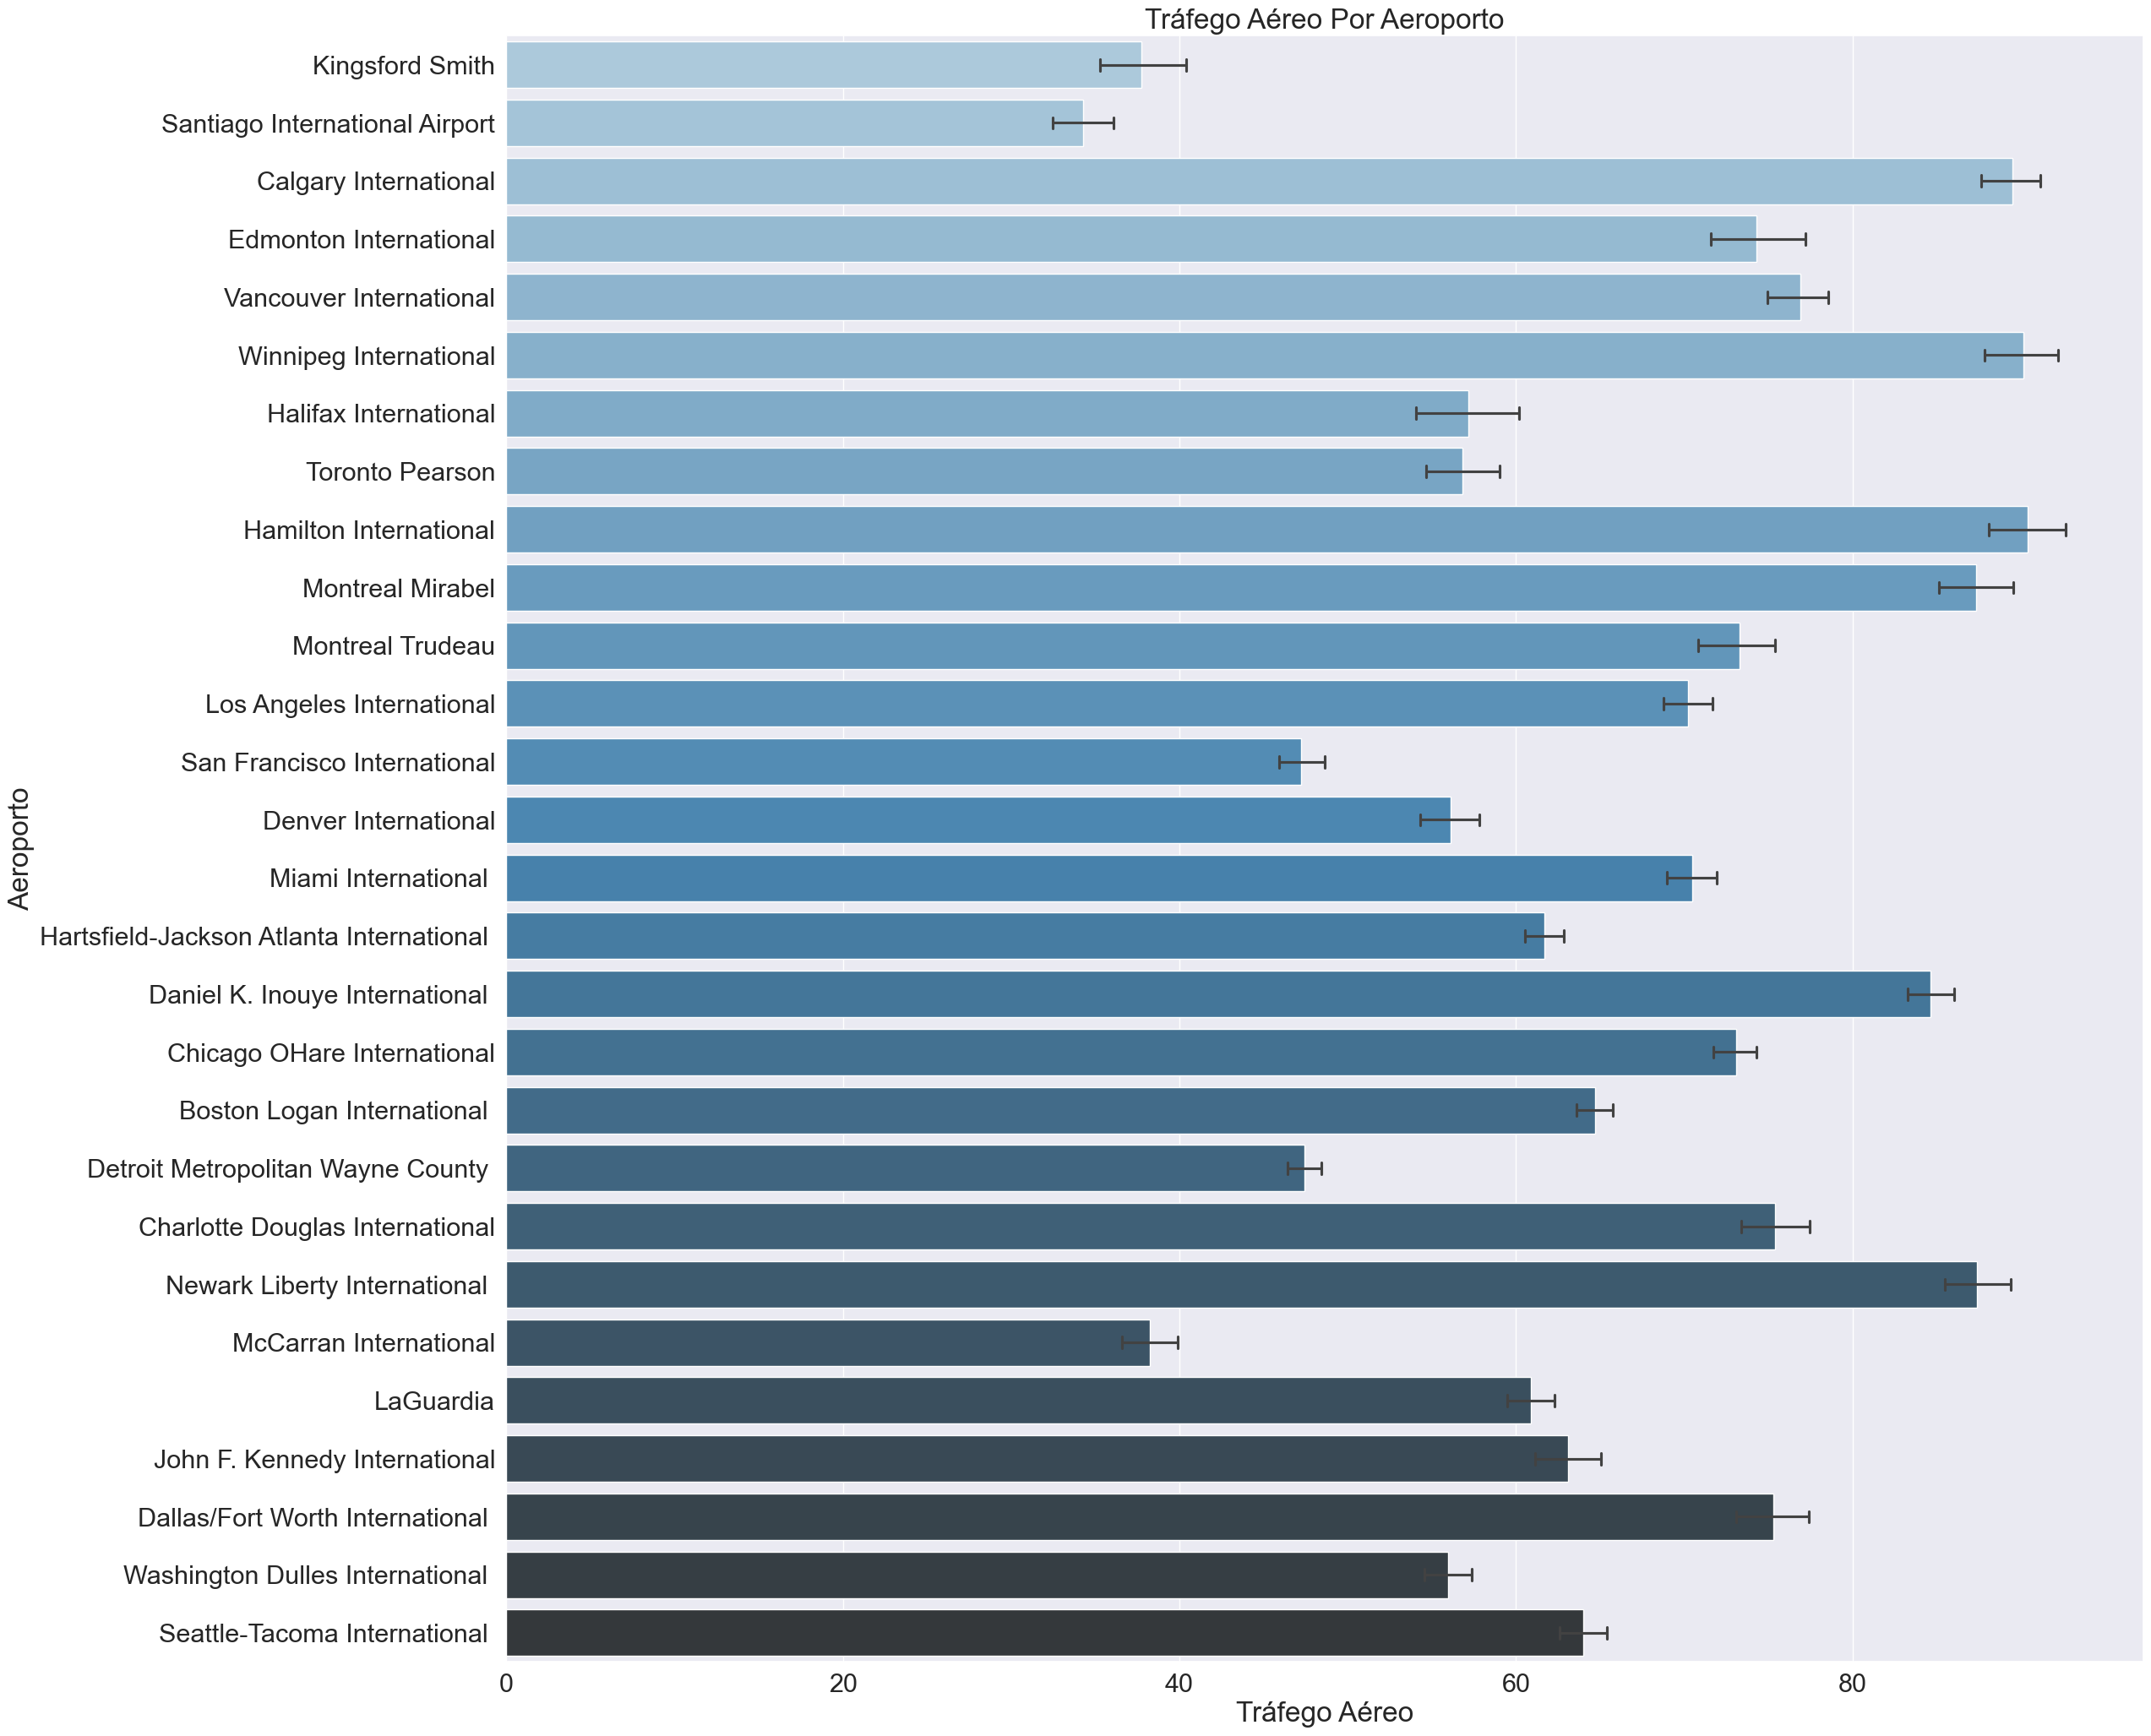

In [15]:
# Dataviz
sns.set(font_scale = 2)
plt.figure(figsize = (25,25))
sns.barplot(x = df.PercentOfBaseline, y = df.AirportName, palette = "Blues_d", capsize = .2)
plt.title("Tráfego Aéreo Por Aeroporto")
plt.xlabel('Tráfego Aéreo')
plt.ylabel('Aeroporto')

Grandes aeroportos internacionais apresentam:

        maior volume de tráfego
        maior variação ao longo do tempo

Aeroportos como:

    Los Angeles International
    Chicago O'Hare
    Dallas/Fort Worth
    JFK

são hubs globais e concentram grande parte do fluxo aéreo.

#### Distribuição do Tráfego por Estado

**Scatter Plot com o tráfego aéreo por estado**

Text(0, 0.5, 'Estado')

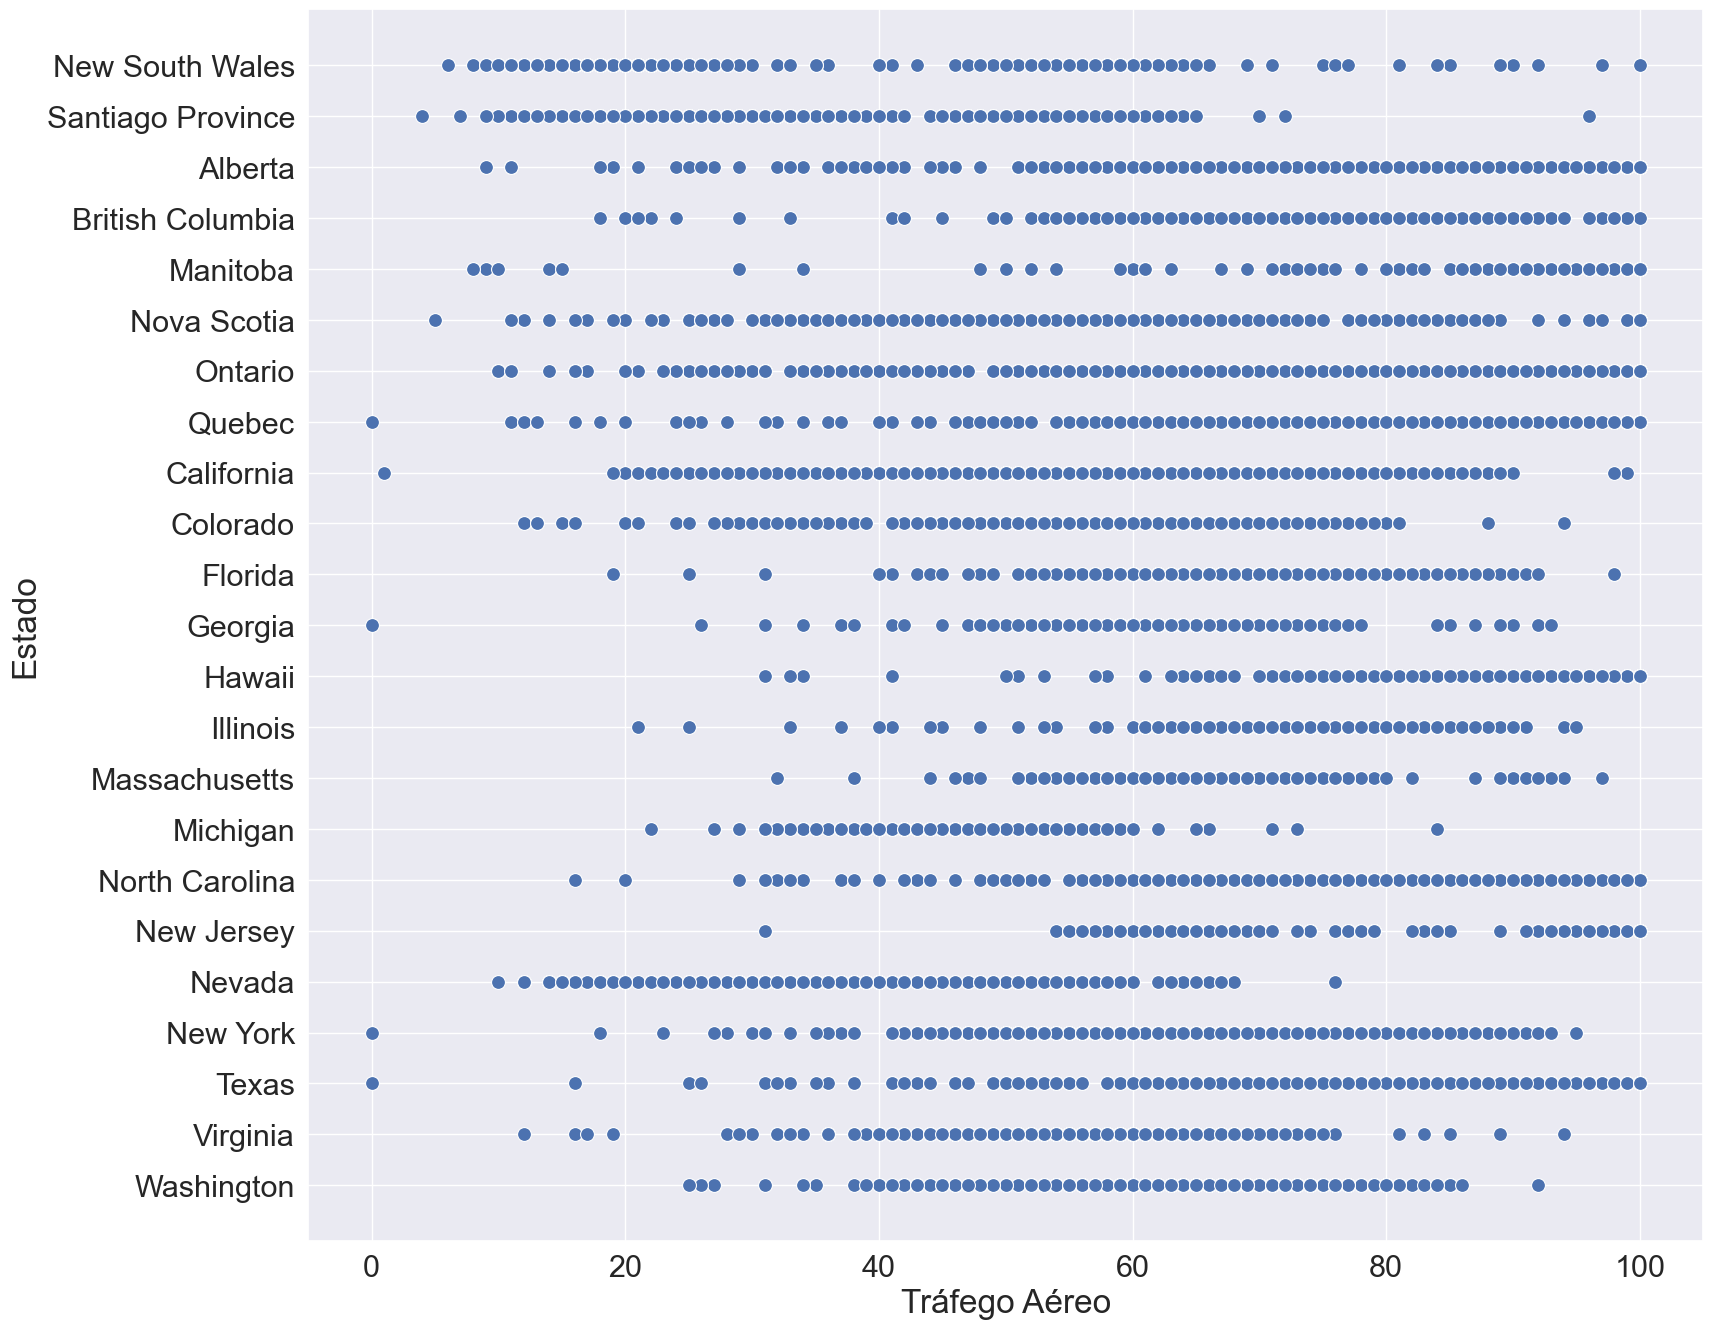

In [16]:
# Dataviz
sns.set(font_scale = 2)
plt.figure(figsize = (18,16))
sns.scatterplot(y = df.State, x = df.PercentOfBaseline, s = 100)
plt.xlabel('Tráfego Aéreo')
plt.ylabel('Estado')

Estados com múltiplos aeroportos apresentam:

    maior concentração de pontos
    maior variabilidade no tráfego

Isso indica diferenças entre aeroportos regionais e hubs internacionais.

#### Evolução Temporal do Tráfego

Podemos também observar o comportamento ao longo do tempo.

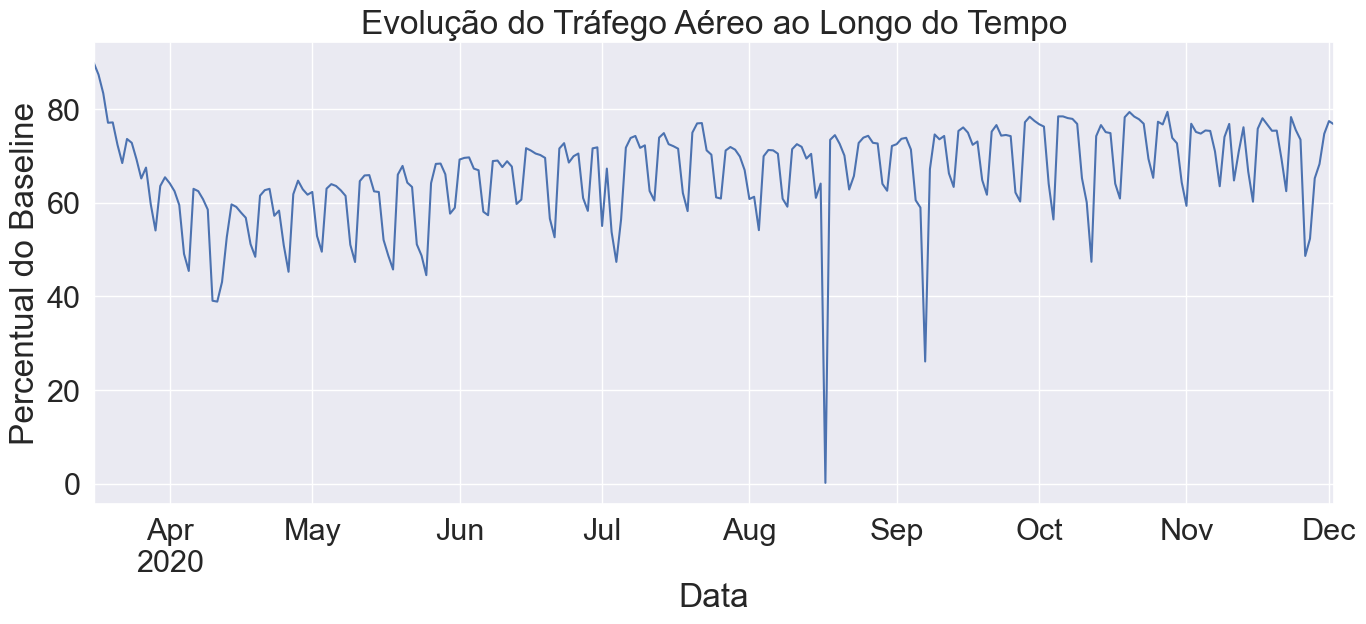

In [17]:
df["Date"] = pd.to_datetime(df["Date"])

trafego_tempo = df.groupby("Date")["PercentOfBaseline"].mean()

plt.figure(figsize=(16,6))

trafego_tempo.plot()

plt.title("Evolução do Tráfego Aéreo ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Percentual do Baseline")

plt.show()

O gráfico temporal permite identificar:

        períodos de queda
        recuperação gradual do tráfego
        padrões sazonais

#### 🌎 Mapa Geográfico dos Aeroportos

O dataset possui a coluna Centroid, que contém coordenadas geográficas.

Exemplo: POINT(151.180087713813 -33.9459774986125)

Precisamos extrair:

latitude | longitude

#### Extraindo Coordenadas

In [18]:
df["Longitude"] = df["Centroid"].str.extract(r'POINT\(([-0-9.]+)')
df["Latitude"] = df["Centroid"].str.extract(r'POINT\([-0-9.]+\s([-0-9.]+)\)')

df["Latitude"] = df["Latitude"].astype(float)
df["Longitude"] = df["Longitude"].astype(float)

#### Mapa Interativo de Aeroportos

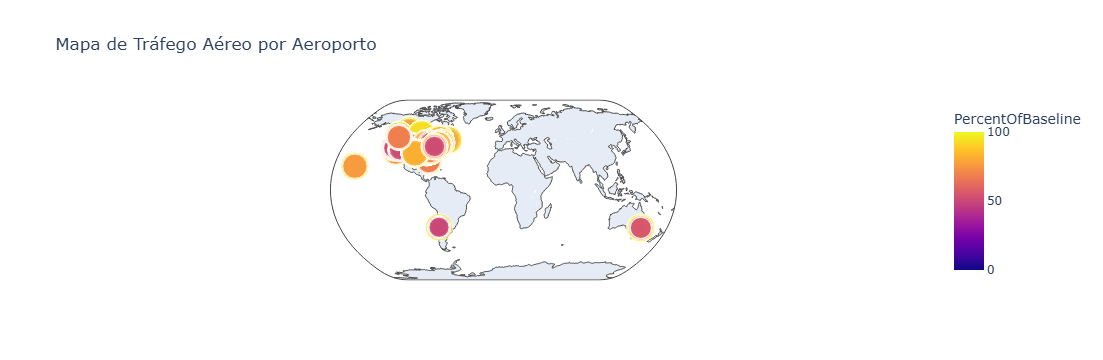

In [19]:
fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    color="PercentOfBaseline",
    hover_name="AirportName",
    size="PercentOfBaseline",
    projection="natural earth",
    title="Mapa de Tráfego Aéreo por Aeroporto"
)

fig.show()

**Esse mapa permite identificar:**

    distribuição geográfica dos aeroportos
    regiões com maior atividade aérea
    concentração de tráfego em hubs internacionais

Os principais hubs identificados incluem:

    Los Angeles
    Chicago
    New York
    Toronto
    Sydney

Esses aeroportos funcionam como centros estratégicos de conexão global.

#### Análise de Tráfego por País no Mapa

In [20]:
trafego_pais = df.groupby("Country")["PercentOfBaseline"].mean().reset_index()

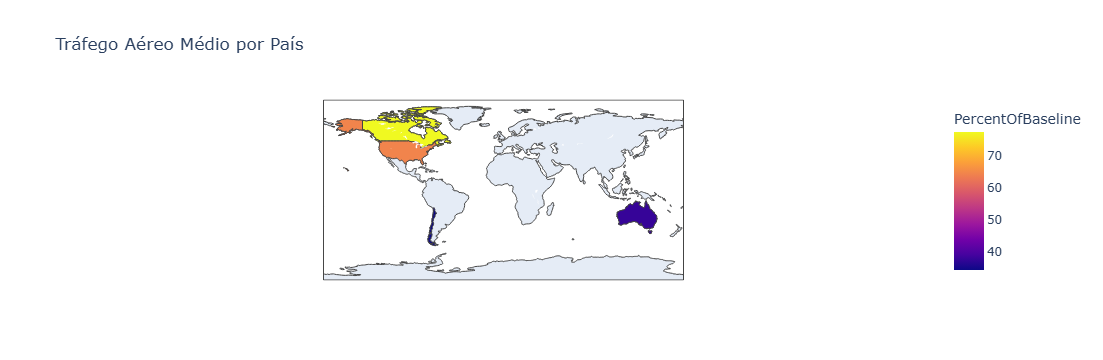

In [21]:
fig = px.choropleth(
    trafego_pais,
    locations="Country",
    locationmode="country names",
    color="PercentOfBaseline",
    title="Tráfego Aéreo Médio por País"
)

fig.show()

#### 1️⃣ Tráfego médio abaixo do normal

O tráfego médio está em torno de 66% do baseline histórico.

Isso sugere uma redução significativa na atividade aérea.

#### 2️⃣ Forte concentração em poucos países

Os dados mostram predominância de:

    Estados Unidos
    Canadá

Esses países possuem os maiores mercados de aviação do mundo.

#### 3️⃣ Aeroportos internacionais concentram o fluxo

Hubs internacionais apresentam:

    maior volume de tráfego
    maior resiliência em períodos de queda
    
#### 4️⃣ Diferença entre aeroportos regionais e hubs

Aeroportos menores apresentam maior volatilidade no tráfego.

#### Conclusão

Este projeto demonstrou como a Análise Exploratória de Dados (EDA) pode revelar padrões importantes no setor de transporte aéreo.

Os resultados mostram que:

    o tráfego aéreo varia significativamente entre países
    grandes hubs aeroportuários mantêm maior estabilidade
    a atividade aérea apresenta forte relação com fatores econômicos e logísticos

Essa análise pode ajudar:

        empresas aéreas
        autoridades aeroportuárias
        analistas de mercado

a compreender melhor o comportamento da demanda por transporte aéreo.

# Fim